# Retail Sales Performance & Profit Optimization Analysis

## Problem Statement:

A retail company wants to analyze its sales data to understand:

Which products and categories perform best
How profit varies across categories and regions
Monthly sales trends and seasonal patterns
Loss-making areas that need improvement

The goal is to generate insights for better business decision-making.

## Data Loading

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Data Cleaning

In [53]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('-', '_')

print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='object')


In [54]:
df.info()
df.isnull().sum()

df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9800 non-null   int64  
 1   order_id       9800 non-null   object 
 2   order_date     9800 non-null   object 
 3   ship_date      9800 non-null   object 
 4   ship_mode      9800 non-null   object 
 5   customer_id    9800 non-null   object 
 6   customer_name  9800 non-null   object 
 7   segment        9800 non-null   object 
 8   country        9800 non-null   object 
 9   city           9800 non-null   object 
 10  state          9800 non-null   object 
 11  postal_code    9789 non-null   float64
 12  region         9800 non-null   object 
 13  product_id     9800 non-null   object 
 14  category       9800 non-null   object 
 15  sub_category   9800 non-null   object 
 16  product_name   9800 non-null   object 
 17  sales          9800 non-null   float64
dtypes: float

In [55]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

profit_col = [col for col in df.columns if 'profit' in col]

print(profit_col)

[]


## Data Handling

In [56]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce') 

df['year'] = df['order_date'].dt.year 
df['month'] = df['order_date'].dt.month

In [57]:
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'year', 'month'],
      dtype='object')


## Sales Distribution Across Product Categories

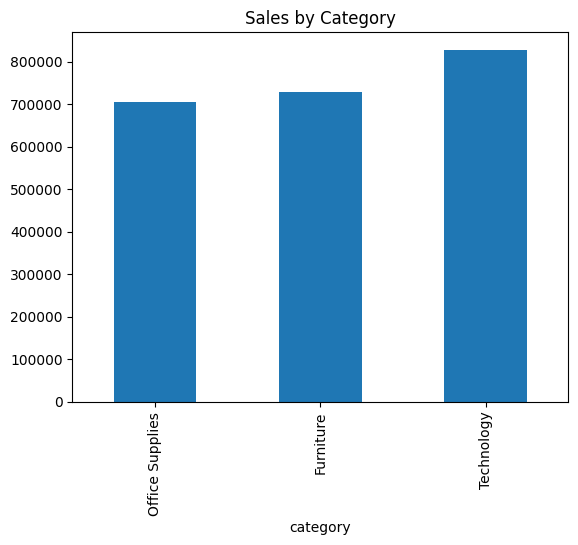

In [58]:
df.groupby('category')['sales'].sum().sort_values().plot(kind='bar')

plt.title('Sales by Category')
plt.show()

## Regional Sales Performance Analysis

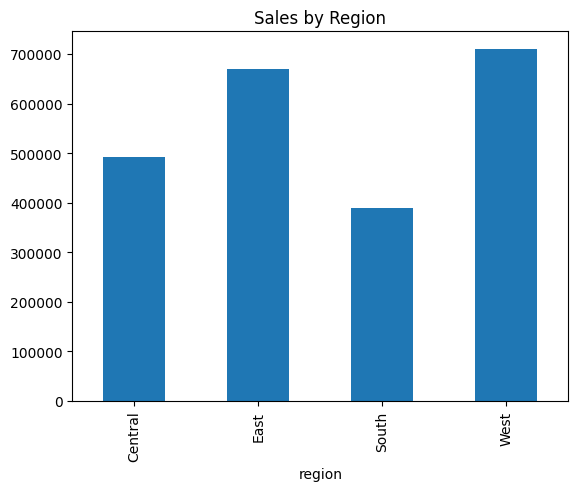

In [59]:
df.groupby('region')['sales'].sum().plot(kind='bar')

plt.title('Sales by Region')
plt.show()

## Monthly Sales Trend Analysis

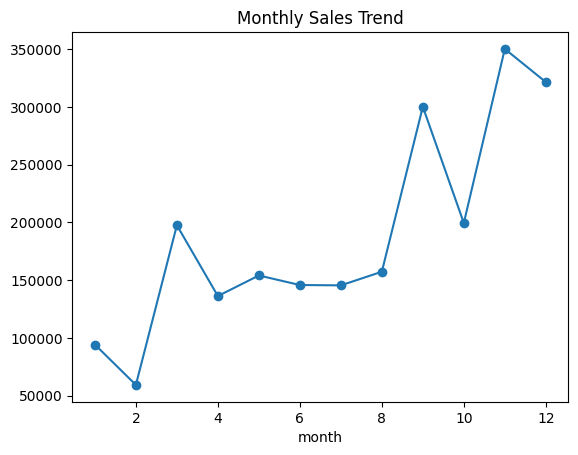

In [60]:
df.groupby('month')['sales'].sum().plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.show()

## Top Performing Sub-Categories Based on Sales

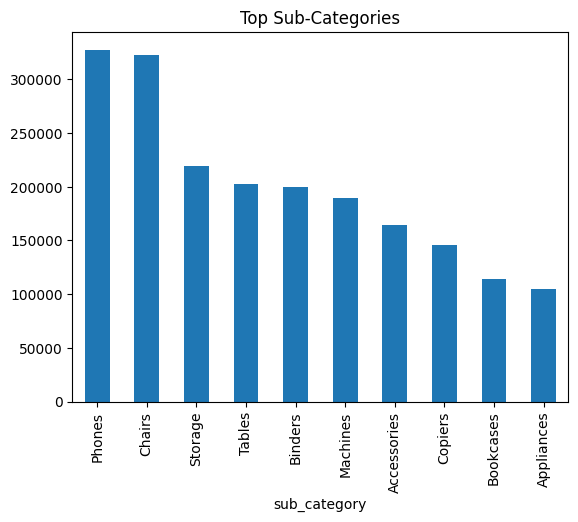

In [61]:
df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('Top Sub-Categories')
plt.show()

## Category-wise Sales Distribution Across Regions

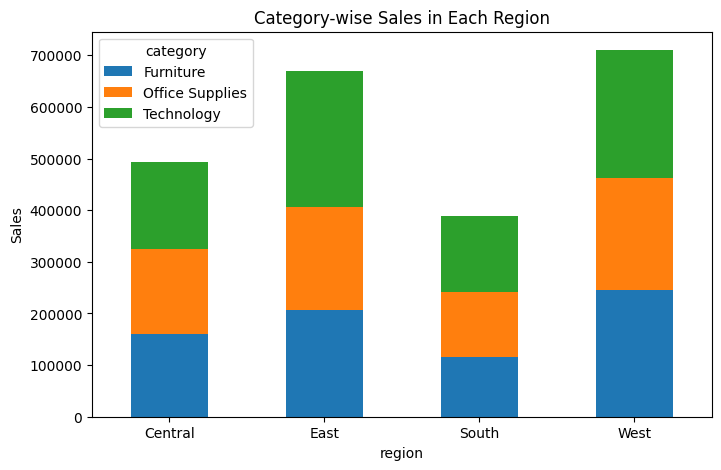

In [62]:
df.groupby(['region', 'category'])['sales'].sum().unstack().plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Category-wise Sales in Each Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

# Key Insights

- Sales vary significantly across different categories, showing uneven product performance.
- Certain regions contribute more to overall revenue, indicating stronger market presence in those areas.
- A small number of sub-categories dominate total sales, showing dependency on key products.
- Monthly sales trends show fluctuations, suggesting seasonal buying patterns.
- Category-wise regional analysis shows that product demand differs across regions.


# Business Recommendations

- Focus marketing efforts on high-performing categories and regions to maximize revenue.
- Improve performance in low-selling regions through targeted campaigns.
- Increase inventory planning for top-performing sub-categories to avoid stock shortages.
- Analyze seasonal trends to optimize promotions and discounts during peak months.
- Diversify product strategy to reduce dependency on a few high-performing sub-categories.


# Conclusion

This project successfully analyzed retail sales data to uncover meaningful business insights. Through exploratory data analysis, key patterns in sales distribution across categories, regions, and time were identified.

The findings can help businesses make data-driven decisions to improve sales performance, optimize inventory management, and enhance regional marketing strategies. Overall, this project demonstrates practical application of data analysis in a real-world retail scenario.